Task 3-5

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load the Fashion MNIST dataset
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize pixel values to the [0,1] range
x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

# For CNN autoencoder: reshape to (num_samples, 28,28,1)
x_train_cnn = np.reshape(x_train, (-1, 28, 28, 1))
x_test_cnn  = np.reshape(x_test,  (-1, 28, 28, 1))

# For Dense autoencoder: flatten images to vectors of length 784
x_train_dense = x_train.reshape(-1, 28*28)
x_test_dense  = x_test.reshape(-1, 28*28)


In [34]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Define the input layer
input_img = Input(shape=(28, 28, 1))

# Encoder: convolutional layers + pooling
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)   # 14x14
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)  # 7x7

# Decoder: upsampling + convolutional layers to reconstruct
x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)                     # 14x14
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)                     # 28x28
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Define the model
cnn_autoencoder = Model(input_img, decoded)
cnn_autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
cnn_autoencoder.summary()


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)          │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_30 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 14, 14, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 7, 7, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 7, 7, 16)            │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_12 (UpSampling2D)      │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_33 (Conv2D)                   │ (None, 14, 14, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_13 (UpSampling2D)      │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_34 (Conv2D)                   │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
from tensorflow.keras.layers import Dense, Flatten, Reshape

# Define the input for flattened images
input_img_dense = Input(shape=(28*28,))

# Encoder: several Dense layers compress the input
encoded_dense = Dense(128, activation='relu')(input_img_dense)
encoded_dense = Dense(64, activation='relu')(encoded_dense)
encoded_dense = Dense(32, activation='relu')(encoded_dense)

# Decoder: mirror the architecture to reconstruct the input
decoded_dense = Dense(64, activation='relu')(encoded_dense)
decoded_dense = Dense(128, activation='relu')(decoded_dense)
decoded_dense = Dense(28*28, activation='sigmoid')(decoded_dense)
# decoded_dense = Reshape((28, 28, 1))(decoded_dense)

# Define the dense autoencoder model
dense_autoencoder = Model(input_img_dense, decoded_dense)
dense_autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
dense_autoencoder.summary()


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)          │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 784)                 │         101,136 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Train the CNN autoencoder
history_cnn = cnn_autoencoder.fit(
    x_train_cnn, x_train_cnn,
    epochs=20,
    batch_size=32,
    shuffle=True,
    validation_data=(x_test_cnn, x_test_cnn)
)

# Train the Dense autoencoder
history_dense = dense_autoencoder.fit(
    x_train_dense, x_train_dense,
    epochs=20,
    batch_size=32,
    shuffle=True,
    validation_data=(x_test_dense, x_test_dense)
)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.3130 - val_loss: 0.2684
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.2645 - val_loss: 0.2639
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.2600 - val_loss: 0.2607
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2580 - val_loss: 0.2591
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.2565 - val_loss: 0.2580
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2556 - val_loss: 0.2574
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.2556 - val_loss: 0.2572
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2552 - val_loss: 0.2564
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.2546 - val_loss: 0.2561
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2537 - val_loss: 0.2559
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.2533 - val_loss: 0.2556
Epoch 12/20
1875/1875 ━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


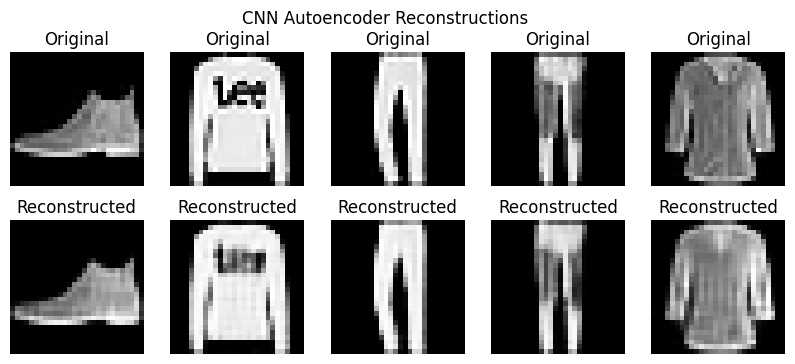

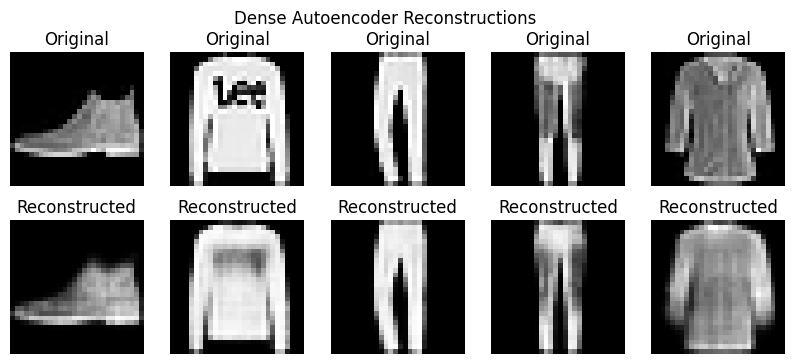

In [37]:
# Get reconstructions for the test set
decoded_imgs_cnn = cnn_autoencoder.predict(x_test_cnn)
decoded_imgs_dense = dense_autoencoder.predict(x_test_dense)
decoded_imgs_dense = decoded_imgs_dense.reshape(-1, 28, 28, 1)

# Function to display original and reconstructed images
def plot_reconstructions(original, reconstructed, title):
    n = 5  # number of images to display
    plt.figure(figsize=(10, 4))
    for i in range(n):
        # Display original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis('off')
        # Display reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Plot reconstructions from CNN autoencoder
plot_reconstructions(x_test_cnn, decoded_imgs_cnn, "CNN Autoencoder Reconstructions")

# Plot reconstructions from Dense autoencoder
plot_reconstructions(x_test_cnn, decoded_imgs_dense, "Dense Autoencoder Reconstructions")


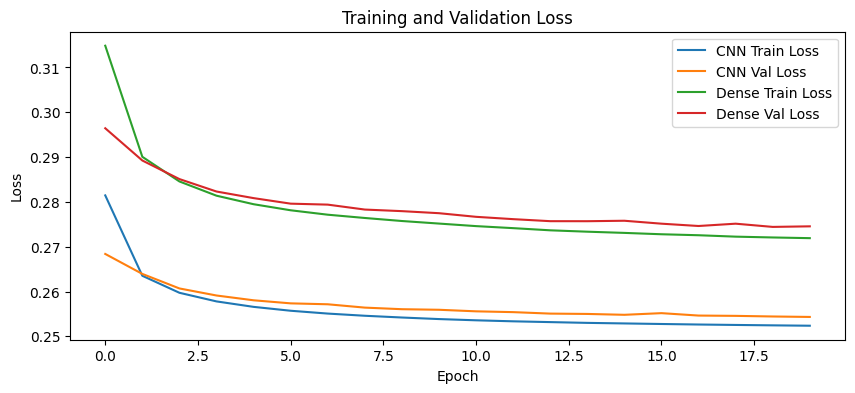

In [38]:
# Plot loss curves for both models
plt.figure(figsize=(10, 4))
plt.plot(history_cnn.history['loss'], label='CNN Train Loss')
plt.plot(history_cnn.history['val_loss'], label='CNN Val Loss')
plt.plot(history_dense.history['loss'], label='Dense Train Loss')
plt.plot(history_dense.history['val_loss'], label='Dense Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [39]:
# Evaluate the CNN Autoencoder
test_loss_cnn = cnn_autoencoder.evaluate(x_test_cnn, x_test_cnn, verbose=0)
print(f"CNN Autoencoder Test Loss: {test_loss_cnn:.4f}")

# Evaluate the Dense Autoencoder
test_loss_dense = dense_autoencoder.evaluate(x_test_dense, x_test_dense, verbose=0)
print(f"Dense Autoencoder Test Loss: {test_loss_dense:.4f}")


CNN Autoencoder Test Loss: 0.2543
Dense Autoencoder Test Loss: 0.2745
